In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\admin\Desktop\Kenya Gender Dev Analysis\Data\Raw\gender_ken pydata assignment.csv')
df = df[df['Year'] <= 2025]

my_indicators = {
    'primary': "School enrollment, primary (gross), gender parity index (GPI)",
    'secondary': "School enrollment, secondary (gross), gender parity index (GPI)",
    'labor': "Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)",
    'parliament': "Proportion of seats held by women in national parliaments (%)",
    'Kenya':"Latest Value by Indicator"
    'Correlation Heatmap'"How the 4 Indicators Relate"
    }


story_df = df[(df['Indicator Name'].isin(my_indicators)) & (df['Year'] <= 2025)]
story_df.sort_values(['Indicator Name', 'Year'])

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value


In [2]:
df.head()

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,Kenya,KEN,2025,Firms with female top manager (% of firms),IC.FRM.FEMM.ZS,17.749350
1,Kenya,KEN,2018,Firms with female top manager (% of firms),IC.FRM.FEMM.ZS,18.115070
2,Kenya,KEN,2013,Firms with female top manager (% of firms),IC.FRM.FEMM.ZS,13.386440
3,Kenya,KEN,2025,Firms with female participation in ownership (...,IC.FRM.FEMO.ZS,36.482521
4,Kenya,KEN,2018,Firms with female participation in ownership (...,IC.FRM.FEMO.ZS,47.456821


##                        Primary School Gender Parity Index Over Time - Kenya

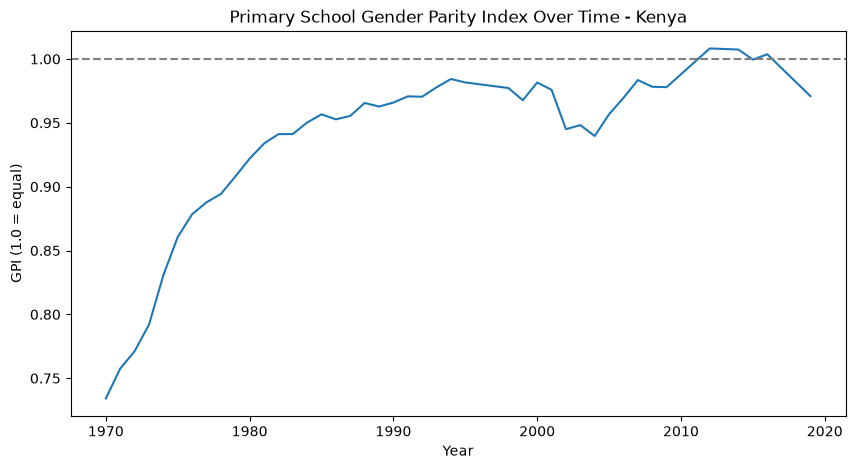

Started at 0.73 in 1970
Ended at 0.97 in 2019
Change: +0.24


In [3]:
# Pulling  out only the rows for the "primary school GPI" indicator, sorted oldest year first
primary = df[df['Indicator Name'] == my_indicators['primary']].sort_values('Year')

# Creating  a blank canvas for the chart, 10 inches wide by 5 inches tall
plt.figure(figsize=(10,5))

# Draw the line: Year along the bottom, GPI value up the side
plt.plot(primary['Year'], primary['Value'])

# Draw a dashed gray horizontal line at 1.0 to mark "perfect equality"
plt.axhline(y=1.0, color='gray', linestyle='--')

# Add the chart's title
plt.title('Primary School Gender Parity Index Over Time - Kenya')

# Labeling  the x-axis (bottom) and y-axis (side)
plt.xlabel('Year')
plt.ylabel('GPI (1.0 = equal)')

# Actually display the chart on screen
plt.show()

# STATS
# .iloc[0] grabs the FIRST row (earliest year, since we sorted above)
start_val = primary.iloc[0]['Value']

# .iloc[-1] grabs the LAST row (most recent year)
end_val = primary.iloc[-1]['Value']

# Simple subtraction: how much did it change overall?
change = end_val - start_val

# Print out a readable summary of the numbers
print(f"Started at {start_val:.2f} in {int(primary.iloc[0]['Year'])}")
print(f"Ended at {end_val:.2f} in {int(primary.iloc[-1]['Year'])}")
print(f"Change: {change:+.2f}")

Shows girls' access to primary education climbing from 0.73 (1970) to 0.97 (2019), briefly touching full parity around 2017. Change: +0.24

## Gender Parity in Education Over Time (Primary vs Secondary) - Kenya

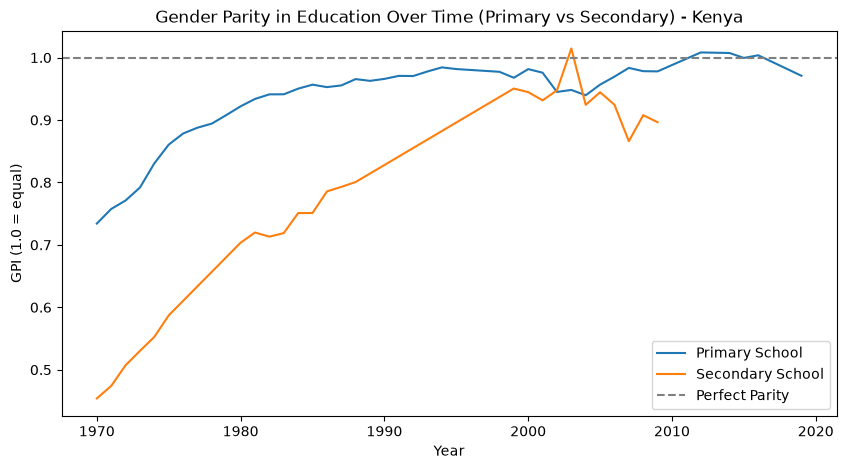

Average gap between primary and secondary: 0.146
Closest they ever got: 2002


In [4]:
# Pulling out the secondary school GPI rows, sorted oldest year first
secondary = df[df['Indicator Name'] == my_indicators['secondary']].sort_values('Year')

# Creating a blank canvas
plt.figure(figsize=(10,5))

# Drawing TWO lines on the same chart, each with a label for the legend
plt.plot(primary['Year'], primary['Value'], label='Primary School')
plt.plot(secondary['Year'], secondary['Value'], label='Secondary School')

# Reference line at perfect parity, also labeled
plt.axhline(y=1.0, color='gray', linestyle='--', label='Perfect Parity')

# Title and axis labels
plt.title('Gender Parity in Education Over Time (Primary vs Secondary) - Kenya')
plt.xlabel('Year')
plt.ylabel('GPI (1.0 = equal)')

# Show the legend box (uses the "label=" text from each line above)
plt.legend()
plt.show()

# STATS
# Join primary and secondary side by side, matched by Year, so we can compare them directly
merged = pd.merge(primary[['Year','Value']], secondary[['Year','Value']], on='Year', suffixes=('_primary','_secondary'))

# Calculate the gap (difference) between the two lines, for every year
merged['gap'] = merged['Value_primary'] - merged['Value_secondary']

# Average that gap across all years
avg_gap = merged['gap'].mean()

# Find the year where the gap was smallest (closest to zero, using absolute value)
closest_year = merged.loc[merged['gap'].abs().idxmin(), 'Year']

print(f"Average gap between primary and secondary: {avg_gap:.3f}")
print(f"Closest they ever got: {int(closest_year)}")

Two lines together — blue (primary) consistently sits above orange (secondary) for most of the timeline, showing secondary school access lagged behind. Average gap: 0.146 (secondary was, on average, about 15 percentage points of parity behind primary), and they came closest together in 2002.

# Female Labor Force Participation Rate Over Time - Kenya

In [5]:
labor_force = story_df[story_df['Indicator Name'] == "Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)"]
labor_force = labor_force.sort_values('Year')

In [6]:
labor_force

,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value


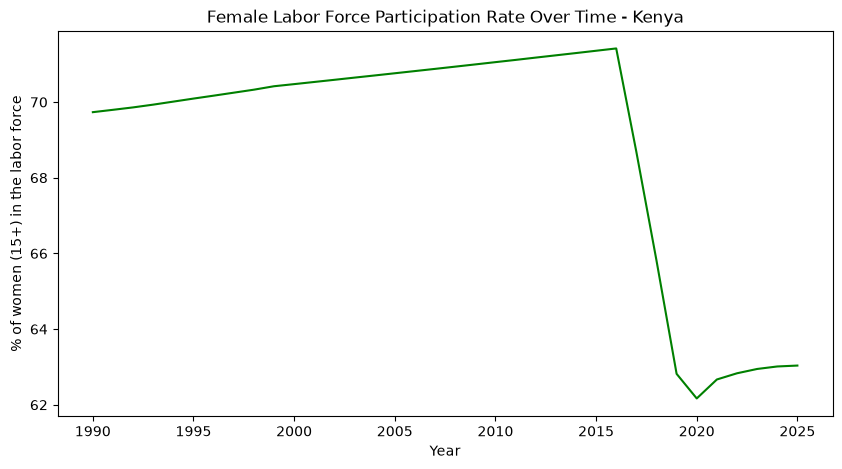

Peak: 71.4% in 2016
Lowest: 62.2% in 2020
Drop from peak to lowest: 9.2 percentage points


In [7]:
# Pull out the labor force participation rows, sorted oldest year first
labor = df[df['Indicator Name'] == my_indicators['labor']].sort_values('Year')

# Create a blank canvas
plt.figure(figsize=(10,5))

# Draw the line in green
plt.plot(labor['Year'], labor['Value'], color='green')

# Title and axis labels
plt.title('Female Labor Force Participation Rate Over Time - Kenya')
plt.xlabel('Year')
plt.ylabel('% of women (15+) in the labor force')
plt.show()

# STATS
# .idxmax() finds the ROW NUMBER of the highest value, .loc[] fetches that whole row
peak_row = labor.loc[labor['Value'].idxmax()]

# .idxmin() finds the ROW NUMBER of the lowest value
low_row = labor.loc[labor['Value'].idxmin()]

# How far did it fall from its best year to its worst year?
drop = peak_row['Value'] - low_row['Value']

print(f"Peak: {peak_row['Value']:.1f}% in {int(peak_row['Year'])}")
print(f"Lowest: {low_row['Value']:.1f}% in {int(low_row['Year'])}")
print(f"Drop from peak to lowest: {drop:.1f} percentage points")

Steady climb from ~69% (1990) to a peak of 71.4% in 2016, then a sharp cliff down to a low of 62.2% in 2020 — a 9.2 percentage point drop, your most striking and still-unexplained finding.

# Proportion of Parliamentary Seats Held by Women - Kenya

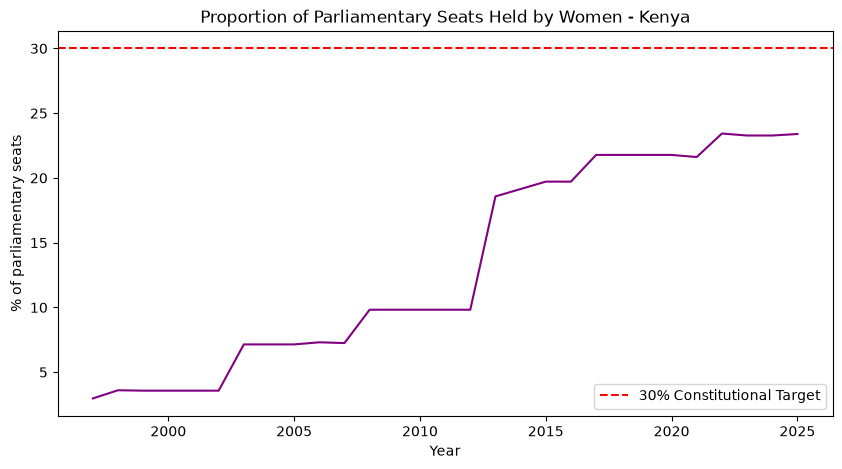

Growth since 1997: +20.4 percentage points
Currently 6.6 percentage points short of the 30% target


In [8]:
# Pulling out the parliament seats rows, sorted oldest year first
parliament = df[df['Indicator Name'] == my_indicators['parliament']].sort_values('Year')

# Creating a blank canvas
plt.figure(figsize=(10,5))

# Drawing the line in purple
plt.plot(parliament['Year'], parliament['Value'], color='purple')

# Drawing a red dashed line at 30% — Kenya's constitutional target
plt.axhline(y=30, color='red', linestyle='--', label='30% Constitutional Target')

# Title and axis labels
plt.title('Proportion of Parliamentary Seats Held by Women - Kenya')
plt.xlabel('Year')
plt.ylabel('% of parliamentary seats')

# Show the legend (so the red line's meaning is visible)
plt.legend()
plt.show()

# STATS
start_val = parliament.iloc[0]['Value']   # earliest year's value
end_val = parliament.iloc[-1]['Value']    # most recent year's value
growth = end_val - start_val              # total change over time

# How far below the 30% target is the most recent value?
gap_to_target = 30 - end_val

print(f"Growth since {int(parliament.iloc[0]['Year'])}: {growth:+.1f} percentage points")
print(f"Currently {gap_to_target:.1f} percentage points short of the 30% target")

Steady stair-step growth from under 3% (1997) to over 23% today, with the red dashed line marking Kenya's 30% constitutional target. Growth: +20.4 points, but still 6.6 points short of that legal target — real progress, not yet complete.

# Latest Value by Indicator - Kenya

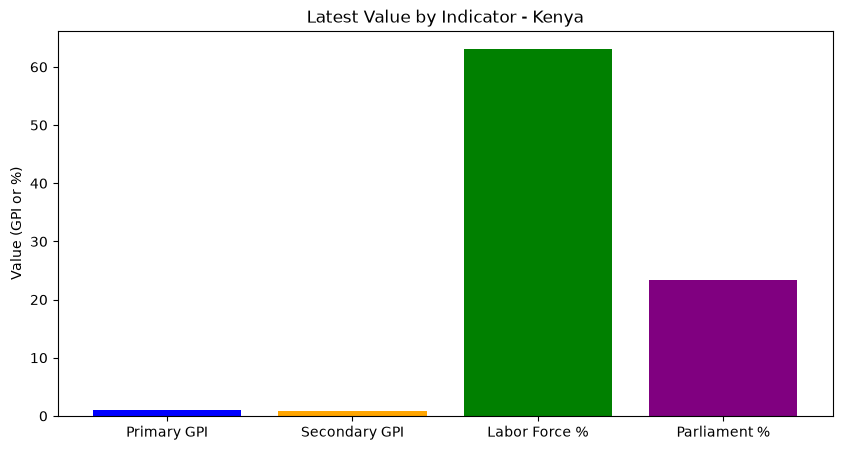

In [9]:
# Grabing the most recent value for each of your 4 indicators
latest_values = {
    'Primary GPI': primary.iloc[-1]['Value'],
    'Secondary GPI': secondary.iloc[-1]['Value'],
    'Labor Force %': labor.iloc[-1]['Value'],
    'Parliament %': parliament.iloc[-1]['Value']
}

# Creating a blank canvas
plt.figure(figsize=(10,5))

# Draw the bars: keys become the x-axis labels, values become the bar heights
plt.bar(latest_values.keys(), latest_values.values(), color=['blue','orange','green','purple'])

plt.title('Latest Value by Indicator - Kenya')
plt.ylabel('Value (GPI or %)')
plt.show()

Compares the most recent value across all 4 indicators side by side. Useful "at a glance" snapshot — though worth noting: this chart mixes different units (GPI ratios around 1.0 vs. percentages up to 70%+) on the same axis, which is why Labor Force and Parliament bars look dramatically taller than the GPI bars —

# Correlation Heatmap: How the 4 Indicators Relate

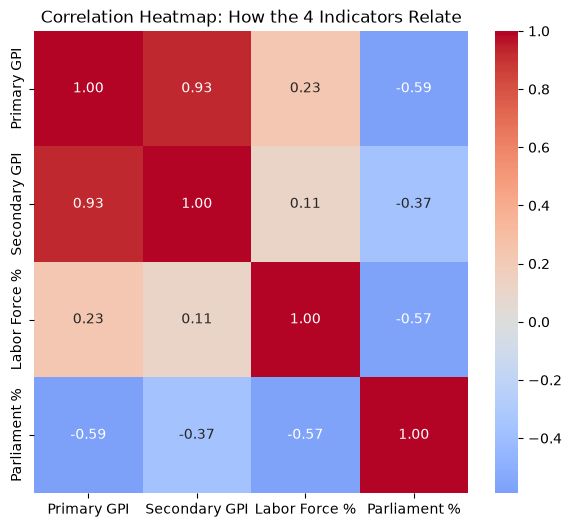

Strongest relationship: Primary GPI & Secondary GPI (r = 0.93)


In [10]:
# Build a table: one row per YEAR, one column per indicator, values = the actual numbers
# .dropna() removes any year where one of the 4 indicators is missing data
pivot = df[df['Indicator Name'].isin(my_indicators.values())].pivot_table(
    index='Year', columns='Indicator Name', values='Value'
).dropna()

# Rename the long column names to short, readable labels
pivot.columns = ['Primary GPI', 'Secondary GPI', 'Labor Force %', 'Parliament %']

# .corr() calculates how closely every pair of columns moves together (-1 to +1)
corr_matrix = pivot.corr()

# Create a blank canvas
plt.figure(figsize=(7,6))

# Drawing the heatmap: annot=True shows the numbers, cmap sets the color scheme,
# center=0 makes 0 sit in the middle of the color scale
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')

plt.title('Correlation Heatmap: How the 4 Indicators Relate')
plt.show()

# STATS
# np.triu(...) keeps only the upper-right half of the grid (avoids counting each pair twice)
# .stack() turns the grid into a simple list of pairs, .idxmax() finds the strongest one
strongest = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().idxmax()
strongest_val = corr_matrix.loc[strongest]

print(f"Strongest relationship: {strongest[0]} & {strongest[1]} (r = {strongest_val:.2f})")

Shows how tightly each pair of indicators moves together. The strongest relationship: Primary GPI & Secondary GPI (r = 0.93) — makes sense, since they both reflect the same underlying "education access" trend. Notably, Parliament % is negatively correlated with all three other indicators (r = -0.37 to -0.59) — meaning as education/labor indicators rose, parliament representation didn't rise in the same years, which is actually consistent with your article's point that political progress followed its own separate timeline (driven by the 2010 Constitution, not gradual social change).
.